# ***Final Assignment: X-Ray images classification***
---
*   Meri Ferretti (10666970)
*   Diana Nigrisoli (10824967)
*   Laura Pozzi (10868694)

In this script our ***second approach*** will be illustrated.

Regarding the dataset, for this option we decided to not just consider all the images as done in the previous approach, but to keep only one picture for patient ensuring that it had a black background but could be either affected by some noise or not.  

Regarding the training, we tried 2 different models:
1.   Transfer learning + Fine tuning using EfficientNetB3 and a customized Fully Connected network
2.   Fine Tuning of a model found in literature from "Bhandari, M., Shahi, T. B., Siku, B., & Neupane, A. (2022). Explanatory classification of CXR images into COVID-19, Pneumonia and Tuberculosis using deep learning and XAI. Computers in Biology and Medicine, 150, 106156."

### Mounting | Importing | Seed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project

/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project


In [ ]:
!pip install keras_ocr

In [ ]:
import os
import sys
import cv2
import math
import json
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
tfk = tf.keras
tfkl = tf.keras.layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import load_model,Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter, defaultdict
import matplotlib.patches as patches
from glob import glob
from PIL import Image
plt.rc('font', size=16) 
import keras_ocr
from functools import partial

In [ ]:
### Random seed for reproducibility
seed = 42   

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

### Creating the dataset for Option 2


N.B. ***We DO NOT recommend to run this section cause It could last a huge amount of time***

#### 1 - Functions' definition

In [ ]:
!pip install tqdm
from tqdm import tqdm

In [ ]:
### Defining ROIs coordinates
img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

In [ ]:
### SINGLE IMAGES MANAGEMENT 

def find_data_1pict(patients_class, data_class):
  (list_pat_unique, counts_pat) = np.unique(patients_class, return_counts=True)
  pat_1pict = division_per_n_pict(list_pat_unique,counts_pat,1) 
  
  single_images = select_image_per_patient(data_class,pat_1pict) 

  return single_images

In [ ]:
### IMAGES COUPLES MANAGEMENT 

def division_per_n_pict(x,y,n_pict):
  return x[y==n_pict]  

#******************************************************************************

def select_image_per_patient(list_image_class, list_patient_set):
  list_img_set = []
  for img in list_image_class:
    for pat in list_patient_set:
      if (img[:6] == pat):
        list_img_set.append(img)
  return list_img_set

#******************************************************************************
def check_noise_couple(img1, img2, id1, id2):
  
  roi1 = img1[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std1 = roi1.std()
  
  roi2 = img1[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std2 = roi2.std()
 
  roi3 = img1[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  std3 = roi3.std()
  
  roi4 = img1[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  std4 = roi4.std()

  roi5 = img1[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  std5 = roi5.std()

  roi6 = img1[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  std6 = roi6.std()

  if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
    return id1
  
  else: 
    roi1 = img2[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
    std1 = roi1.std()
    
    roi2 = img2[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
    std2 = roi2.std()
  
    roi3 = img2[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
    std3 = roi3.std()
    
    roi4 = img2[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
    std4 = roi4.std()

    roi5 = img2[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
    std5 = roi5.std()

    roi6 = img2[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
    std6 = roi6.std()

    if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
      return id2

    else: 
      return 0


#*******************************************************************************
def check_negative(img1,img2, id1, id2):
  #computing img1 ROIs' means
  roi1_img1 = img1[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  mean1_img1 = roi1_img1.mean()
  
  roi2_img1 = img1[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  mean2_img1 = roi2_img1.mean()
 
  roi3_img1 = img1[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  mean3_img1 = roi3_img1.mean()
  
  roi4_img1 = img1[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  mean4_img1 = roi4_img1.mean()

  roi5_img1 = img1[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  mean5_img1 = roi5_img1.mean()

  roi6_img1 = img1[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  mean6_img1 = roi6_img1.mean() 

  #computing img2 ROIs' means
  roi1_img2 = img2[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  mean1_img2 = roi2_img1.mean()
  
  roi2_img2 = img2[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  mean2_img2 = roi2_img2.mean()
 
  roi3_img2 = img2[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  mean3_img2 = roi3_img2.mean()
  
  roi4_img2 = img2[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  mean4_img2 = roi4_img2.mean()

  roi5_img2 = img2[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  mean5_img2 = roi5_img2.mean()

  roi6_img2 = img1[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  mean6_img2 = roi6_img2.mean() 

  #summing all the means
  mean_tot_img1 = mean1_img1 + mean2_img1 + mean3_img1 + mean4_img1 + mean5_img1 + mean6_img1
  mean_tot_img2 = mean1_img2 + mean2_img2 + mean3_img2 + mean4_img2 + mean5_img2 + mean6_img2

  if (mean_tot_img1 > mean_tot_img2):
    #it means that the img1 has white background => img2 has black background
    return id2 
  
  else: 
    return id1



#******************************************************************************
def discard_negative_and_notnoisy(patients_class, data_class, img_class_dir):
  (list_pat_unique, counts_pat) = np.unique(patients_class, return_counts=True)

  pat_2pict = division_per_n_pict(list_pat_unique,counts_pat,2) 
  #we consider only the patients that have 2 imgs

  couple_images = select_image_per_patient(data_class,pat_2pict) 
  #array of images, the first two should belong to the same patient and so on 

  i=0

  img_kept=[]

  while(i<len(couple_images)): #we select one couple at a time
    image_path_1 = os.path.join(img_class_dir,couple_images[i])
    image_path_2 =  os.path.join(img_class_dir,couple_images[i+1])
    image_1= cv2.imread(image_path_1)
    image_2= cv2.imread(image_path_2)

    #1. check the noise - function 'check_noise'
    #if one img is noiy keep it and discard the other 
    #if both are NOT noisy skip to step 2
    x = check_noise_couple(image_1, image_2, couple_images[i], couple_images[i+1])
    if(x!=0):
      img_kept.append(x)
    else:
      #2. check if one is the negative of the other - function 'check_negative'
      #keep the one that has black background 
      y=check_negative(image_1, image_2, couple_images[i], couple_images[i+1])
      img_kept.append(y)
      
    i+=2

  return img_kept

In [ ]:
### WHITE IMAGES DETECTION

def check_white_image(img): #check one image at a time
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  mean1 = roi1.mean()
  
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  mean2 = roi2.mean()
 
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  mean3 = roi3.mean()
  
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  mean4 = roi4.mean()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  mean5 = roi5.mean()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  mean6 = roi6.mean() 

  if (mean5>240): img_returned = 1 #white_ground
  elif (mean1>208 or mean2>208 or mean3>208 or mean4>208 or mean5>208 or mean6>208):
    if sum([mean < 85 for mean in(mean1,mean2,mean3,mean4,mean5,mean6)]) >=2: 
      img_returned = 2 #black_ground
    else : img_returned = 1 #white_ground
  else:
    img_returned = 2 #black gorund

  return img_returned

def check_white_class(data_class, img_class_dir): #check a batch at the time

  img_white = []
  img_no_white = []
  for img in tqdm(data_class):
    image_path = os.path.join(img_class_dir,img)
    image = cv2.imread(image_path)
    check = check_white_image(image)
    if check == 1 : img_white.append(img)
    else: img_no_white.append(img)

  return img_white, img_no_white

In [ ]:
# SPLITTING 
def split_perclass_random(imgs_class, train_ratio, val_ratio, test_ratio):
  
  train, remaining = train_test_split(imgs_class, test_size=1 - train_ratio, shuffle = True, random_state = seed)
  val, test = train_test_split(remaining, test_size=test_ratio/(test_ratio + val_ratio), shuffle = True, random_state = seed) 

  return train, val, test

In [ ]:
# LOAD IN NEW FOLDERS + REMOVE TEXT + CHANGE WHITE TO BLACK (if needed)

def midpoint(x1, y1, x2, y2):
    x_mid = int((x1 + x2)/2)
    y_mid = int((y1 + y2)/2)
    return (x_mid, y_mid)

def inpaint_text(img, pipeline):
    prediction_groups = pipeline.recognize([img])
    mask = np.zeros(img.shape[:2], dtype="uint8")
    for box in prediction_groups[0]:
        x0, y0 = box[1][0]
        x1, y1 = box[1][1] 
        x2, y2 = box[1][2]
        x3, y3 = box[1][3] 
        
        x_mid0, y_mid0 = midpoint(x1, y1, x2, y2)
        x_mid1, y_mi1 = midpoint(x0, y0, x3, y3)
        
        thickness = int(math.sqrt( (x2 - x1)**2 + (y2 - y1)**2 ))
        
        cv2.line(mask, (x_mid0, y_mid0), (x_mid1, y_mi1), 255,    
        thickness)
        img = cv2.inpaint(img, mask, 7, cv2.INPAINT_NS)
                 
    return(img)

def remove_text(img_path, img_code, pipeline):
  img = cv2.imread(img_path)
  img_noText = inpaint_text(img, pipeline)

  fixed_dir='/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Images_fixed'
  new_path= os.path.join(fixed_dir,img_code)
  cv2.imwrite(new_path,img_noText)
  return new_path

def remove_text_and_convert_background(img_path, img_code, pipeline):
  
  img = cv2.imread(img_path)
  img_noText = inpaint_text(img, pipeline)
  img_conv = abs(255-img_noText) 

  fixed_dir='/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Images_white_fixed'
  new_path= os.path.join(fixed_dir,img_code)
  cv2.imwrite(new_path,img_conv)

  return new_path
  


def load_in_folder (source, destination, normal_set, pneumo_set, tube_set, white_normal, white_pneumo, white_tube): 
  pipeline = keras_ocr.pipeline.Pipeline()

  for f in normal_set:
    if f not in white_normal:
      path_old=source + '/' + 'Normal'+ '/' + f
      path_new=remove_text(path_old, f, pipeline)
      shutil.copy(path_new, destination + '/' + 'Normal'+ '/' + f )
    else:
      path_old=source + '/' + 'Normal'+ '/' + f
      path_new=remove_text_and_convert_background(path_old, f, pipeline)
      shutil.copy(path_new, destination + '/' + 'Normal'+ '/' + f )

  for f in pneumo_set:
    if f not in white_pneumo:
      path_old=source + '/' + 'Pneumonia'+ '/' + f
      path_new=remove_text(path_old, f, pipeline)
      shutil.copy(path_new, destination + '/' + 'Pneumonia'+ '/' + f )
    else:
      path_old=source + '/' + 'Pneumonia'+ '/' + f
      path_new=remove_text_and_convert_background(path_old, f, pipeline)
      shutil.copy(path_new, destination + '/' + 'Pneumonia'+ '/' + f )

  for f in tube_set:
    if f not in white_tube:
      path_old=source + '/' + 'Tuberculosis'+ '/' + f
      path_new=remove_text(path_old, f, pipeline)
      shutil.copy(path_new, destination + '/' + 'Tuberculosis'+ '/' + f )
    else:
      path_old=source + '/' + 'Tuberculosis'+ '/' + f
      path_new=remove_text_and_convert_background(path_old, f, pipeline)
      shutil.copy(path_new, destination + '/' + 'Tuberculosis'+ '/' + f )

  return

#### 2 - Pipeline

In [ ]:
### Loading resized images 
normal_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Normal'
tube_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Tuberculosis'
pneumo_dir = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized/Pneumonia'

In [ ]:
print('Normal:', len(os.listdir(normal_dir)))
print('Pneumonia:', len(os.listdir(pneumo_dir)))
print('Tuberculosis:', len(os.listdir(tube_dir)))

Normal: 9354
Pneumonia: 4250
Tuberculosis: 1866


In [ ]:
labels = pd.read_csv('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/labels_train.csv')
labels_df = pd.DataFrame(labels)

In [ ]:
y = labels_df["label"]
x = labels_df["file"]

y_array = y.to_numpy()
print(y_array.shape)
x_array = x.to_numpy()
print(x_array.shape)

(15470,)
(15470,)


In [ ]:
def division_per_class(x,y,class_name,n_sample = None):
  return x[y==MAPPING[class_name]] 

In [ ]:
MAPPING = {
    "Normal": "N",
    "Pneumonia": "P",
    "Tuberculosis": "T",
}
print(MAPPING)

{'Normal': 'N', 'Pneumonia': 'P', 'Tuberculosis': 'T'}


In [ ]:
normal = division_per_class(x_array,y_array,"Normal")
pneumo = division_per_class(x_array,y_array,"Pneumonia")
tube = division_per_class(x_array,y_array,"Tuberculosis")

In [ ]:
patients = []
patients_norm = []
patients_pneumo = []
patients_tube = []

for sample in normal:
    patients.append(sample[:6])
    patients_norm.append(sample[:6])
    
for sample in tube:
    patients.append(sample[:6])
    patients_tube.append(sample[:6])

for sample in pneumo:
    patients.append(sample[:6])
    patients_pneumo.append(sample[:6])

1) Among "double" images (one patient -> 2 images) discard the negative (white background) or the NOT noisy one

In [ ]:
kept_images_norm = discard_negative_and_notnoisy (patients_norm, normal, normal_dir)
kept_images_pneumo = discard_negative_and_notnoisy (patients_pneumo, pneumo, pneumo_dir)
kept_images_tube = discard_negative_and_notnoisy (patients_tube, tube, tube_dir) 

2) Creating a global array for each class containing "unique" images (one patient -> one image) 

In [ ]:
# Arrays of already "unique" images (one patient -> one image)
single_norm = find_data_1pict(patients_norm, normal)
single_pneumo = find_data_1pict(patients_pneumo, pneumo)
single_tube = find_data_1pict(patients_tube, tube)

# Arrays of "unique" images
tot_norm = kept_images_norm + single_norm
tot_pneumo = kept_images_pneumo + single_pneumo
tot_tube = kept_images_tube + single_tube

3) Checking if among these global arrays images with white background are present and saving their codes

In [ ]:
white_normal = check_white_class(tot_norm, normal_dir)
white_pneumo = check_white_class(tot_pneumo, pneumo_dir)
white_tube = check_white_class(tot_tube, tube_dir)

4) Splitting into training, validation and test set while converting images with white background to images with black background

In [ ]:
normal_train, normal_val, normal_test = split_perclass_random(tot_norm, 0.7, 0.2, 0.1)
pneumo_train, pneumo_val, pneumo_test = split_perclass_random(tot_pneumo, 0.7, 0.2, 0.1)
tube_train, tube_val, tube_test = split_perclass_random(tot_tube, 0.7, 0.2, 0.1)

5) Loading in new folders

In [ ]:
source = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/DataDivided_resized'
destination_train = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/Train'
destination_val = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/Validation'
destination_test = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/Test'

In [ ]:
load_in_folder(source, destination_train, normal_train, pneumo_train, tube_train, white_normal, white_pneumo, white_tube)
load_in_folder(source, destination_val, normal_val, pneumo_val, tube_val, white_normal, white_pneumo, white_tube)
load_in_folder(source, destination_test, normal_test, pneumo_test, tube_test, white_normal, white_pneumo, white_tube)

### Data generators

In [ ]:
train_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/Train'
val_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/Validation'
test_dir = '/content/drive/MyDrive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/Test'

In [ ]:
### Defining ROIs coordinates
img_size = 256 # image height = image width
roi_size = 10 # ROI height = ROI width

# roi 1 (top-left)
w1_start = 4
h1_start = 32
# roi 2 (top-right)
w2_start = img_size - 4 - roi_size
h2_start = 4
# roi 3 (center-right)
w3_start = img_size - 4 - roi_size
h3_start = 120
# roi 4 (bottom-right)
w4_start = img_size - 4 - roi_size
h4_start = img_size - 32 - roi_size
# roi 5 (bottom-left)
w5_start = 4
h5_start = img_size - 4 - roi_size
# roi 6 (center-left)
w6_start = 4
h6_start = 120

In [ ]:
### Preprocessing function

def check_noise(img):
  
  noisy = False
  
  roi1 = img[h1_start:h1_start+roi_size, w1_start:w1_start+roi_size]
  std1 = roi1.std()
  
  roi2 = img[h2_start:h2_start+roi_size, w2_start:w2_start+roi_size]
  std2 = roi2.std()
 
  roi3 = img[h3_start:h3_start+roi_size, w3_start:w3_start+roi_size]
  std3 = roi3.std()
  
  roi4 = img[h4_start:h4_start+roi_size, w4_start:w4_start+roi_size]
  std4 = roi4.std()

  roi5 = img[h5_start:h5_start+roi_size, w5_start:w5_start+roi_size]
  std5 = roi5.std()

  roi6 = img[h6_start:h6_start+roi_size, w6_start:w6_start+roi_size]
  std6 = roi6.std()

  if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
    noisy = True
    
  return noisy

def equalize(image):

  grayimg = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  grayimg = np.uint8(grayimg)
  
  # Equalizing each channel individually
  image_eq = cv2.equalizeHist(grayimg)
 
  # Stacking the equalized channels back into a single image
  image_equal = np.stack((image_eq,image_eq,image_eq), axis=2)

  return image_equal


def apply_transf_gen (image):
  params = transforms_gen.get_random_transform(image.shape)
  x = transforms_gen.apply_transform(image, params)
  return x


def filter_function_train(image):
  
  noisy = check_noise(image)
  if noisy :
    image = cv2.medianBlur(image, 5)
    image = equalize(image)
    image = apply_transf_gen(image)
    return image

  else: 
    image = equalize(image)
    image = apply_transf_gen(image)
    return image


def filter_function(image):
  
  noisy = check_noise(image)
  if noisy :
    image = cv2.medianBlur(image, 5)
    image = equalize(image)
    return image

  else: 
    image = equalize(image)
    return image

In [ ]:
img_height = 256
img_width = 256
batch_size = 64

transforms_gen = ImageDataGenerator(
    fill_mode = 'constant',
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    horizontal_flip = True,
    zoom_range = 0.1,
)

# With augmentations
train_datagen = ImageDataGenerator(
    preprocessing_function = filter_function_train) 

validation_datagen = ImageDataGenerator(
    preprocessing_function = filter_function)

test_datagen = ImageDataGenerator(
    preprocessing_function = filter_function)


### Online importing
train_dataset = train_datagen.flow_from_directory(
    directory = train_dir,
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = True) 

validation_dataset = validation_datagen.flow_from_directory(
    directory = val_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False) 

test_dataset = test_datagen.flow_from_directory(
    directory = test_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False)

Found 8458 images belonging to 3 classes.
Found 2417 images belonging to 3 classes.
Found 1211 images belonging to 3 classes.


### Training 1
Transfer Learning + Fine Tuning using EfficientNetB3

#### 1 - Model definition

In [ ]:
### Functions used to define and build the model

# Preprocessing to be applied to the input images
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_feat_extractor (img_height: int, img_width: int) -> tf.keras.Model:
    ## network: features extractor
    net = tfk.applications.EfficientNetB3(
          include_top = False,
          weights = "imagenet", 
          input_shape = (img_height, img_width, 3)
          ) 
    net.trainable = False 
    return net 

def build_model(feat_extractor,img_height,img_width,num_classes) -> tf.keras.Model:
    # input of the model
    inputs = tfk.Input(shape=(img_height,img_width,3))

    x = preprocess_input(inputs)
    x = feat_extractor(x, training = False)

    # Classificator: rebuild top
    dropout_rate = 0.4
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    x = tfkl.GlobalAveragePooling2D()(x)
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    x = tfkl.Dense(
        256, 
        activation='relu',
        kernel_initializer = tfk.initializers.HeUniform(seed)
    )(x)
    x = tfkl.Dropout(dropout_rate, seed=seed)(x)
    outputs = tfkl.Dense(
              num_classes, 
              activation='softmax',
              kernel_initializer = tfk.initializers.GlorotUniform(seed),
              kernel_regularizer = tfk.regularizers.L2(0.01),
              #bias_initializer=lambda _, dtype: tf.convert_to_tensor(freqs, dtype=dtype)
    )(x)

    # Connecting input and output through the Model class
    model = tfk.Model(inputs=inputs, outputs=outputs, name='model')

    return model


### MODEL COMPILE
def model_compile (model, learn_rate) ->None:
    optimizer=tfk.optimizers.Adam(learning_rate = learn_rate)
    model.compile(
          loss=tfk.losses.CategoricalCrossentropy(), 
          optimizer= optimizer,
          metrics='accuracy'
    )

In [ ]:
### Functions used in the evaluation phase 

def plot_history(history):
    hist = history
    plt.figure(figsize=(15, 5))
    plt.plot(hist["accuracy"], label="Training", alpha=0.8, color="#ff7f0e")
    plt.plot(hist["val_accuracy"], label="Validation", alpha=0.8, color="#4D61E2")
    plt.ylim(0, 1)
    plt.title("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    plt.figure(figsize=(15, 5))
    plt.plot(hist["loss"], label="Training", alpha=0.8, color="#ff7f0e")
    plt.plot(hist["val_loss"], label="Validation", alpha=0.8, color="#4D61E2")
    plt.title("loss")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()

def evaluate(model: tf.keras.Model,dataset) -> None:
    predictions = model.predict(dataset)

    y_test = dataset.classes
    pred_number = np.argmax(predictions, axis=-1)
    compute_metrics(y_test, pred_number)


def compute_metrics(y_test, pred_number):
  
    # Computing confusion matrix
    cm = confusion_matrix(y_test, pred_number)

    # Computing classification metrics
    accuracy = accuracy_score(y_test, pred_number)
    precision = precision_score(y_test, pred_number, average='macro')
    recall = recall_score(y_test, pred_number, average='macro')
    f1 = f1_score(y_test, pred_number, average='weighted')

    # Printing classification metrics
    print('Accuracy:',accuracy.round(4))
    print('Precision:',precision.round(4))
    print('Recall:',recall.round(4))
    print('F1:',f1.round(4))

    # Plotting confusion matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm.T, xticklabels=list(train_dataset.class_indices), yticklabels=list(train_dataset.class_indices), annot=True)
    plt.xlabel('True labels')
    plt.ylabel('Predicted labels')
    plt.show()

    print(classification_report(y_test, pred_number, target_names=labels))


In [ ]:
### Defining the CNN: EfficientNetB3
net = build_feat_extractor(img_height, img_width)

### Building model structure
tl_model = build_model(net,img_height,img_width,3)

tl_model.summary()

43941136/43941136 [==============================] - 4s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb3 (Functional)  (None, 8, 8, 1536)       10783535  
                                                                 
 dropout (Dropout)           (None, 8, 8, 1536)        0         
                                                                 
 global_average_pooling2d (G  (None, 1536)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_1 (Dropout)         (None, 1536)              0         
                                                                 
 dense (Dense)               (None, 256)               393472 

In [ ]:
### Model Compiling
lear_rate_tl = 1e-3
model_compile(tl_model,lear_rate_tl)

In [ ]:
### Class weights

from collections import Counter
counter = Counter(train_dataset.classes)
number_classes = 3                          

n_samples = float(sum(counter.values()))       

class_weights = {class_id : n_samples/(num_images) for class_id, num_images in counter.items()}                     

print(counter.values())
print(class_weights)

dict_values([5124, 2313, 1021])
{0: 1.650663544106167, 1: 3.6567228707306527, 2: 8.284035259549462}


#### 2 - Transfer Learning

In [ ]:
# Defining callbacks (early stopping) to be used in the Transfer Learning part
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/tl_models_opt2/weights_improvement_{epoch:02d}_{val_accuracy:.2f}', 
        monitor='val_accuracy', save_best_only=False, save_weights_only=False, 
        mode='max')

]

# Fitting the model on our training dataset
history = tl_model.fit(
    x = train_dataset,
    epochs = 40, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_tl, 
    class_weight =  class_weights
).history

In [ ]:
### Loading the best model from the Transfer Learning part 
tl_model = tfk.models.load_model('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/tl_models_opt2/best_model_opt2')

In [ ]:
### PREDICTION on validation set - just to check the correct upload
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(tl_model, validation_dataset)

In [ ]:
### PREDICTION on test set
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(tl_model, test_dataset)

#### 3 - Fine Tuning

In [ ]:
ft_model = tl_model 

ft_model.get_layer('efficientnetb3').trainable = True
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers):
   print(i, layer.name, layer.trainable)

In [ ]:
# Freeze first N layers
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers[:118]):
   layer.trainable=False
for i, layer in enumerate(ft_model.get_layer('efficientnetb3').layers):
   print(i, layer.name, layer.trainable)

In [ ]:
initial_learning_rate = 1e-5
model_compile(ft_model,initial_learning_rate)

In [ ]:
### Defining callbacks to be used in the Fine Tuning part
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/Dataset_Option2/ft_models_aug/weights_improvement_{epoch:02d}_{val_accuracy:.2f}', 
        monitor='val_accuracy', save_best_only=True, save_weights_only=False, 
        mode='max'),
    tfk.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', patience=5, factor=0.5, min_lr=1e-9)
]

### Fitting the model on the training dataset
history = ft_model.fit(
    x = train_dataset,
    epochs = 200, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_ft, 
    class_weight =  class_weights,
).history

#### 4 - Evaluation

In [ ]:
### Loading the best model from the Fine Tuning part
best_model = tf.keras.models.load_model('/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/ft_models_opt2/best_model_opt2')

38/38 [==============================] - 635s 17s/step
Accuracy: 0.9524
Precision: 0.9485
Recall: 0.9064
F1: 0.9512


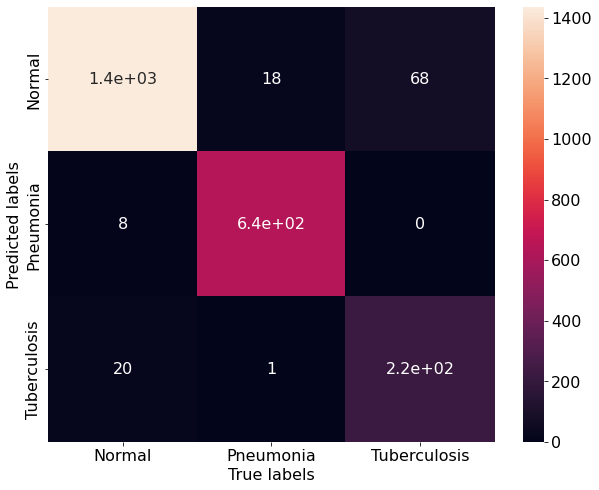

              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96      1464
   Pneumonia       0.99      0.97      0.98       661
Tuberculosis       0.91      0.77      0.83       292

    accuracy                           0.95      2417
   macro avg       0.95      0.91      0.93      2417
weighted avg       0.95      0.95      0.95      2417



In [ ]:
### PREDICTION on validation set - just to check the correct upload
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(best_model, validation_dataset)

19/19 [==============================] - 284s 16s/step
Accuracy: 0.9513
Precision: 0.9569
Recall: 0.9052
F1: 0.9502


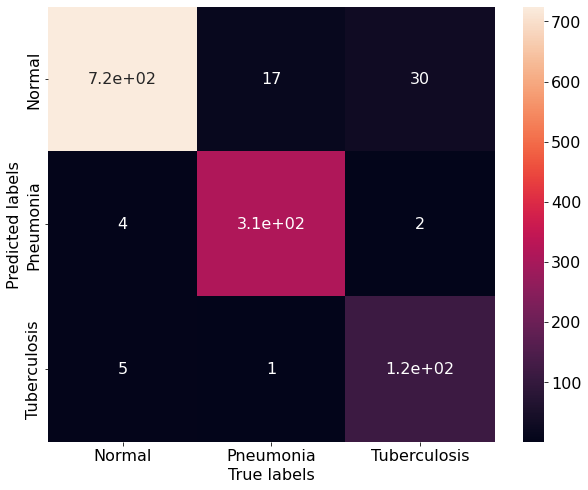

              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       733
   Pneumonia       0.98      0.95      0.96       331
Tuberculosis       0.95      0.78      0.86       147

    accuracy                           0.95      1211
   macro avg       0.96      0.91      0.93      1211
weighted avg       0.95      0.95      0.95      1211



In [ ]:
### PREDICTION on test set
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(best_model, test_dataset)

#### 5 - TTA

In [ ]:
test_datagen_tta = ImageDataGenerator()
val_datagen_tta = ImageDataGenerator()

val_dataset_tta = val_datagen_tta.flow_from_directory(
    directory = val_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False)

test_dataset_tta = test_datagen_tta.flow_from_directory(
    directory = test_dir, 
    color_mode = 'rgb',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes = None,
    seed = seed,
    shuffle = False)

Found 2417 images belonging to 3 classes.
Found 1211 images belonging to 3 classes.


In [ ]:
# Insert here the path of the model which you would like to apply the TTA to 
path = '/content/drive/My Drive/Lab_Applied_AI/Applied_AI_project/ft_models_opt2/best_model_opt2'

In [ ]:
def apply_Zoom (image):
  params = ZoomShift_gen.get_random_transform(image.shape)
  x = ZoomShift_gen.apply_transform(image, params)
  return x

def apply_Flip (image):
  params = Flip_gen.get_random_transform(image.shape)
  x = Flip_gen.apply_transform(image, params)
  return x

############# final pre-processing function ########

def preprocessing_funct_Zoom(image):
  image = filter_function(image)
  image = apply_Zoom(image)
  return image

def preprocessing_funct_Flip(image):
  image = filter_function(image)
  image = apply_Flip(image)
  return image

In [ ]:
ZoomShift_gen = ImageDataGenerator(
    fill_mode = 'constant',
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.1,
)

Flip_gen = ImageDataGenerator(
    horizontal_flip=True
)

In [ ]:
class AugmentedModel:
    def __init__(self, original_model) -> None:
        self.model = tf.keras.models.load_model(path)

        self.augmentations = {
            "None": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  filter_function
            ),
            "Flip": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  preprocessing_funct_Flip
            ),
            "ZoomShift": tf.keras.preprocessing.image.ImageDataGenerator(
                preprocessing_function =  preprocessing_funct_Zoom
            ),
        }

    def predict(self, X):
        preds_tta = []

        for name, aug in self.augmentations.items():
            x = aug.flow(X, shuffle = False)
            preds = self.model.predict(x, verbose=False)
            preds_tta.append(preds)

        out = np.mean(preds_tta, axis=0)
        out = tf.argmax(out, axis=-1)

        return out

Accuracy: 0.9549
Precision: 0.9483
Recall: 0.9098
F1: 0.9538


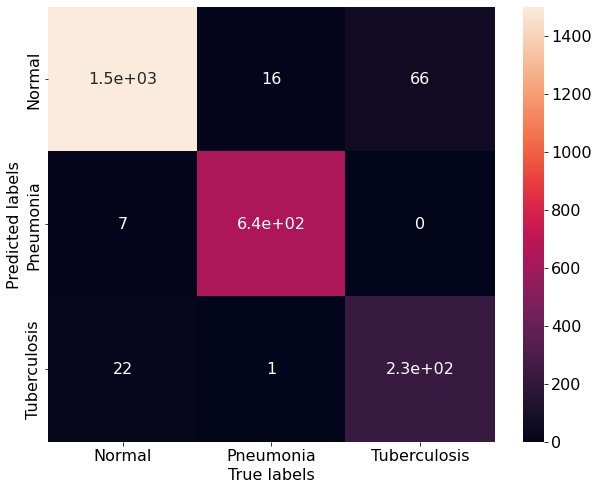

              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96      1528
   Pneumonia       0.99      0.97      0.98       661
Tuberculosis       0.91      0.77      0.84       292

    accuracy                           0.95      2481
   macro avg       0.95      0.91      0.93      2481
weighted avg       0.95      0.95      0.95      2481



In [ ]:
M = AugmentedModel(path)

# Validation set
idx = len(val_dataset_tta)
all_preds = []
all_labs = []
for (X, y) in val_dataset_tta:
    all_preds.extend(M.predict(X))
    all_labs.extend(tf.argmax(y, axis=-1))
    idx -= 1
    print("|" + "#"*(len(val_dataset_tta) - idx) + " "*(idx + 1) + "|", end="\r")
    if idx < 0:
        break

labels = ['Normal','Pneumonia','Tuberculosis']
compute_metrics(all_labs, all_preds)

Accuracy: 0.9553
Precision: 0.9575
Recall: 0.9138
F1: 0.9545


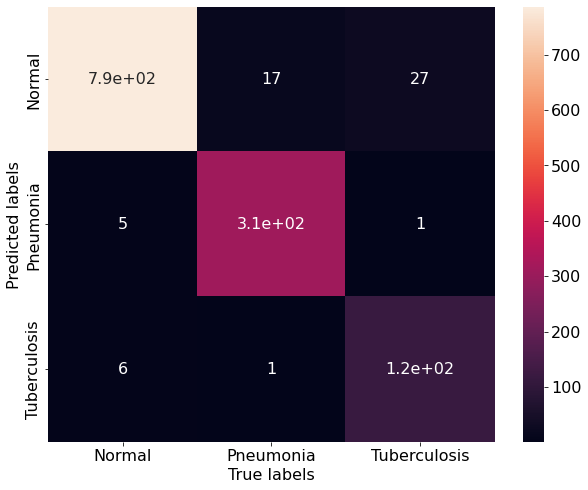

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       797
   Pneumonia       0.98      0.95      0.96       331
Tuberculosis       0.94      0.81      0.87       147

    accuracy                           0.96      1275
   macro avg       0.96      0.91      0.93      1275
weighted avg       0.96      0.96      0.95      1275



In [ ]:
M = AugmentedModel(path)

# Test set
idx = len(test_dataset_tta)
all_preds = []
all_labs = []
for (X, y) in test_dataset_tta:
    all_preds.extend(M.predict(X))
    all_labs.extend(tf.argmax(y, axis=-1))
    idx -= 1
    print("|" + "#"*(len(test_dataset_tta) - idx) + " "*(idx + 1) + "|", end="\r")
    if idx < 0:
        break

labels = ['Normal','Pneumonia','Tuberculosis']
compute_metrics(all_labs, all_preds)

### Training 2
Fine Tuning of a model found in literature from "Bhandari, M., Shahi, T. B., Siku, B., & Neupane, A. (2022). Explanatory classification of CXR images into COVID-19, Pneumonia and Tuberculosis using deep learning and XAI. Computers in Biology and Medicine, 150, 106156."

#### 1 - Model definition

In [ ]:
def build_classifier(input_shape, classes):
  input_layer=tfkl.Input(shape=input_shape, name='Input')
  cnn=tfkl.Conv2D(filters=3,kernel_size=3,padding="same", activation="relu")(input_layer)
  cnn=tfkl.Conv2D(filters=32, kernel_size=3, padding="same", activation="relu")(cnn)
  cnn=tfkl.MaxPooling2D(pool_size=2,strides=2)(cnn)
  cnn = tfkl.Dropout(0.05, seed=seed)(cnn)
  cnn=tfkl.Conv2D(filters=96, kernel_size=3, padding="same", activation="relu")(cnn)
  cnn=tfkl.MaxPooling2D(pool_size=2,strides=2)(cnn)
  cnn = tfkl.Dropout(0.1, seed=seed)(cnn)
  cnn=tfkl.Conv2D(filters=128, kernel_size=3, padding="same", activation="relu")(cnn)
  cnn=tfkl.MaxPooling2D(pool_size=2,strides=2)(cnn)
  cnn = tfkl.Dropout(0.1, seed=seed)(cnn)
  cnn=tfkl.Conv2D(filters=256, kernel_size=3, padding="same", activation="relu")(cnn)
  cnn=tfkl.MaxPooling2D(pool_size=2,strides=2)(cnn)
  cnn = tfkl.Dropout(0.1, seed=seed)(cnn)
  cnn=tfkl.Flatten()(cnn)
  cnn=tfkl.Dense(512, activation='relu')(cnn)
  cnn=tfkl.Dropout(0.45)(cnn)
  output_layer = tfkl.Dense(classes, activation='softmax')(cnn)
  model = tfk.Model(inputs=input_layer, outputs=output_layer, name='model')
  optimizer=tfk.optimizers.Adam(learning_rate = learn_rate)
  model.compile(
          loss=tfk.losses.CategoricalCrossentropy(), 
          optimizer= optimizer,
          metrics='accuracy'
    )

  return model

In [ ]:
learn_rate = 1e-3
model = build_classifier((img_height,img_width,3),3)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 256, 256, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 3)       84        
                                                                 
 conv2d_1 (Conv2D)           (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 32)     0         
 )                                                               
                                                                 
 dropout_3 (Dropout)         (None, 128, 128, 32)      0         
                                                                 
 conv2d_2 (Conv2D)           (None, 128, 128, 96)      27744     
                                                             

#### 2 - Fine Tuning

In [ ]:
### Model fitting 

callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/My Drive/Applied_AI/Project/article_model3/weights_improvement_{epoch:02d}_{val_accuracy:.2f}', 
        monitor='val_accuracy', save_best_only=True, save_weights_only=False, 
        mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-8)
    ]

# Fitting the model on our training dataset
history = model.fit(
    x = train_dataset,
    epochs = 100, 
    initial_epoch = 0,
    validation_data = validation_dataset,
    callbacks = callbacks_tl, 
).history


#### 3 - Evalutation

In [ ]:
best_model=tfk.models.load_model('/content/drive/MyDrive/Applied_AI/Project/article_model3/weights_improvement_17_0.95')

38/38 [==============================] - 13s 331ms/step
Accuracy: 0.9454
Precision: 0.9284
Recall: 0.9075
F1: 0.9447


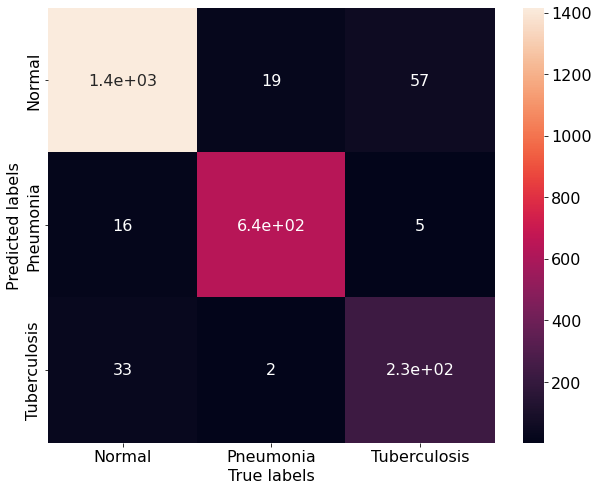

              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96      1464
   Pneumonia       0.97      0.97      0.97       661
Tuberculosis       0.87      0.79      0.83       292

    accuracy                           0.95      2417
   macro avg       0.93      0.91      0.92      2417
weighted avg       0.94      0.95      0.94      2417



In [ ]:
### PREDICTION on validation dataset
labels = ['Normal','Pneumonia','Tuberculosis']
evaluate(best_model, validation_dataset)

19/19 [==============================] - 6s 315ms/step
Accuracy: 0.948
Precision: 0.9371
Recall: 0.9253
F1: 0.9478


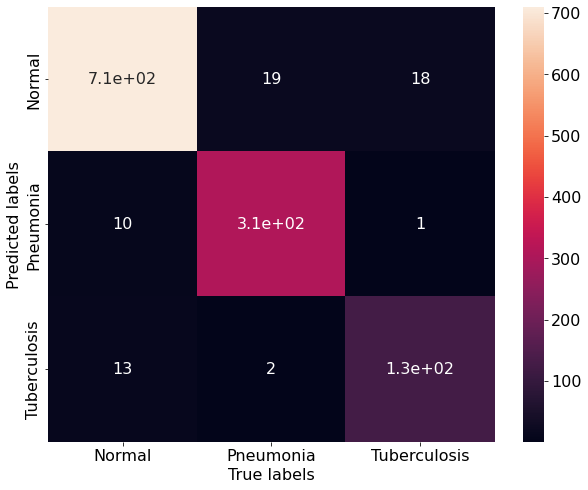

              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       733
   Pneumonia       0.97      0.94      0.95       331
Tuberculosis       0.90      0.87      0.88       147

    accuracy                           0.95      1211
   macro avg       0.94      0.93      0.93      1211
weighted avg       0.95      0.95      0.95      1211



In [ ]:
evaluate(best_model, test_dataset)